In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [5]:
df = pd.read_csv("./보간_평균_결측치처리_데이터.csv")
df['일자']=pd.to_datetime(df['일자'])
df['series_id'] = df['사업소'].astype(str) + "_" + df['호기'].astype(str)
df = df.sort_values(['series_id', '일자'])
df.head()

,일자,사업소,기온,습도,풍향,풍속,강수량,호기,SOX,NOX,먼지,산소,유량,온도,series_id
0,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,1호기,0.0,2.24,0.0,20.78,63.80,40.38,분당_1호기
8,2023-01-02,분당,-7.45,63.39,324.52,1.44,0.0,1호기,0.0,2.87,0.0,20.85,36.01,26.45,분당_1호기
16,2023-01-03,분당,-7.28,56.97,325.07,1.49,0.0,1호기,0.0,3.39,0.0,20.85,30.71,21.52,분당_1호기
24,2023-01-04,분당,-5.12,68.63,324.83,1.50,0.0,1호기,0.0,10.08,0.0,18.73,27639.45,68.56,분당_1호기
32,2023-01-05,분당,-4.20,72.47,324.25,1.42,0.0,1호기,0.0,12.73,0.0,15.51,59172.55,127.94,분당_1호기


In [7]:
for unit_id in df['series_id'].unique():
    sub_df = df[df['series_id'] == unit_id]
    full_range = pd.date_range(start=sub_df['일자'].min(), end=sub_df['일자'].max())
    missing_dates = full_range.difference(sub_df['일자'])
    print(unit_id, missing_dates)

분당_1호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_2호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_3호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_4호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_5호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_6호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_7호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
분당_8호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_3A호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_3B호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_4A호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_4B호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_5A호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_5B호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_6A호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
삼천포_6B호기 DatetimeIndex([], dtype='datetime64[ns]', freq=None)
여수_1호기 DatetimeIndex([],

In [8]:
df.isna().sum()

일자           0
사업소          0
기온           0
습도           0
풍향           0
풍속           0
강수량          0
호기           0
SOX          0
NOX          0
먼지           0
산소           0
유량           0
온도           0
series_id    0
dtype: int64

## 시계열 분해

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 일자 타입 변환
df = pd.read_csv("./보간_평균_결측치처리_데이터.csv")
df['일자'] = pd.to_datetime(df['일자'])

# 사업소별로 호기를 통합한 NOX 총합 또는 평균 생성 (여기선 평균 사용)
df_grouped = df.groupby(['일자', '사업소'])['NOX'].mean().reset_index()

# 시계열 분해 함수
def decompose_by_station(df_grouped, station_name, model='additive', freq=7):
    df_station = df_grouped[df_grouped['사업소'] == station_name].copy()
    df_station.set_index('일자', inplace=True)
    # df_station = df_station.asfreq('D')  # 날짜 누락 시 NaN으로 채움

    # 보간 (누락된 날짜 채우기)
    # df_station['NOX'] = df_station['NOX'].interpolate(method='linear')

    # 시계열 분해
    result = seasonal_decompose(df_station['NOX'], model=model, period=freq)

    # 시각화
    result.plot()
    plt.suptitle(f"{station_name} NOX 시계열 분해 ({model, freq})", fontsize=14)
    plt.tight_layout()
    plt.show()

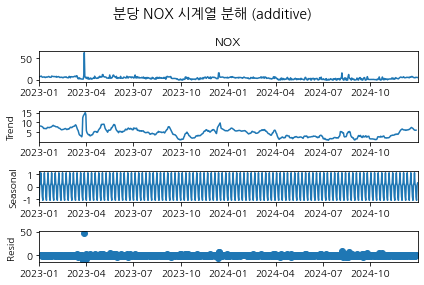

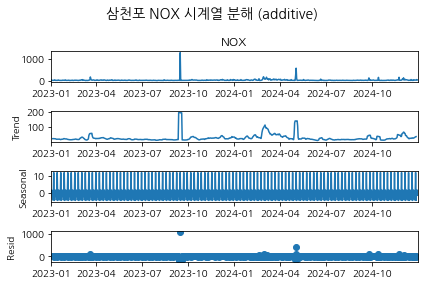

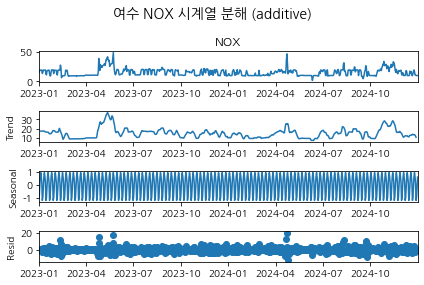

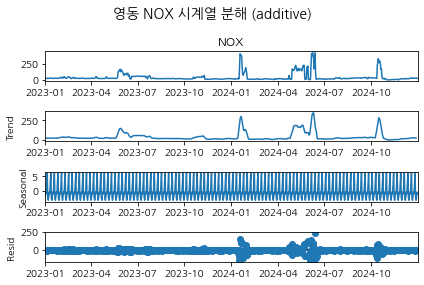

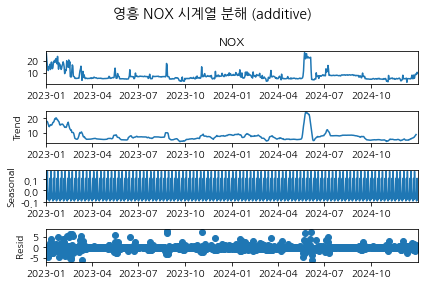

In [ ]:
# frep = 7
for station in df_grouped['사업소'].unique():
    decompose_by_station(df_grouped, station)

## 이상치 처리

In [9]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

In [10]:
df['rolling_mean'] = df['NOX'].rolling(window=7, center=True).mean()
df['residual'] = df['NOX'] - df['rolling_mean']
# Residual 기준 이상치
outliers = df['residual'].abs() > (df['residual'].std() * 3)

In [ ]:
df.loc[outliers].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량,호기,SOX,NOX,먼지,산소,유량,온도
사업소,,,,,,,,,,,,,
분당,1,1,1,1,1,1,1,1,1,1,1,1,1
삼천포,39,39,39,39,39,39,39,39,39,39,39,39,39
영동,16,16,16,16,16,16,16,16,16,16,16,16,16


In [35]:
df_preprocessed[:20]

,일자,사업소,기온,습도,풍향,풍속,강수량,호기,SOX,NOX,먼지,산소,유량,온도,NOX_original,rolling_mean,is_outlier
0,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,1호기,0.0,2.24,0.0,20.78,63.80,40.38,2.24,NaN,False
1,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,2호기,0.0,10.47,0.0,15.45,52086.15,145.54,10.47,NaN,False
2,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,3호기,0.0,9.61,0.0,15.52,57196.79,122.21,9.61,NaN,False
3,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,4호기,0.0,10.38,0.0,15.51,55297.96,104.23,10.38,8.351429,False
4,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,5호기,0.0,10.46,0.0,15.46,58676.38,105.30,10.46,8.261429,False
5,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,6호기,0.0,7.97,0.0,15.59,53715.60,110.46,7.97,7.714286,False
6,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,7호기,0.0,7.33,0.0,15.40,59320.62,105.81,7.33,7.320000,False
7,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,8호기,0.0,1.61,0.0,20.83,190.40,18.00,1.61,6.940000,False
8,2023-01-02,분당,-7.45,63.39,324.52,1.44,0.0,8호기,0.0,6.64,0.0,17.68,36897.59,74.08,6.64,6.888571,False
9,2023-01-02,분당,-7.45,63.39,324.52,1.44,0.0,7호기,0.0,6.85,0.0,15.41,59384.22,108.22,6.85,7.238571,False


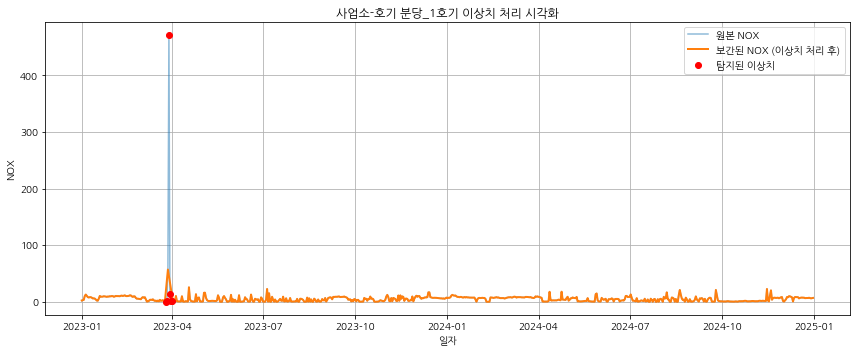

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 전처리 + 이상치 위치 반환
def preprocess_unit_with_outlier_tracking(df_unit):
    df_unit = df_unit.sort_values('일자').reset_index(drop=True)

    # 원본 복사
    df_unit['NOX_original'] = df_unit['NOX']

    # rolling 평균 기반 잔차 계산
    df_unit['rolling_mean'] = df_unit['NOX'].rolling(window=7, center=True).mean()
    residual = df_unit['NOX'] - df_unit['rolling_mean']
    threshold = residual.std() * 3

    # 이상치 마스크 생성
    outlier_mask = residual.abs() > threshold
    df_unit['is_outlier'] = outlier_mask

    # 이상치 → NaN 후 선형 보간
    df_unit.loc[outlier_mask, 'NOX'] = np.nan
    df_unit['NOX'] = df_unit['NOX'].interpolate(method='linear', limit_direction='both')

    return df_unit

# 시각화 함수: 하나의 unit_id에 대해
def plot_outlier_handling(df_unit, unit_id):
    plt.figure(figsize=(12, 5))

    plt.plot(df_unit['일자'], df_unit['NOX_original'], label='원본 NOX', alpha=0.5)
    plt.plot(df_unit['일자'], df_unit['NOX'], label='보간된 NOX (이상치 처리 후)', linewidth=2)
    plt.scatter(df_unit.loc[df_unit['is_outlier'], '일자'],
                df_unit.loc[df_unit['is_outlier'], 'NOX_original'],
                color='red', label='탐지된 이상치', zorder=3)

    plt.title(f"사업소-호기 {unit_id} 이상치 처리 시각화")
    plt.xlabel("일자")
    plt.ylabel("NOX")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 전체 처리
df_preprocessed = df.groupby('series_id').apply(preprocess_unit_with_outlier_tracking).reset_index(drop=True)

# 예시 시각화 (하나의 사업소-호기 선택)
sample_unit = df_preprocessed['series_id'].unique()[0]  # 예: 첫 번째 조합
plot_outlier_handling(df_preprocessed[df_preprocessed['series_id'] == sample_unit], sample_unit)

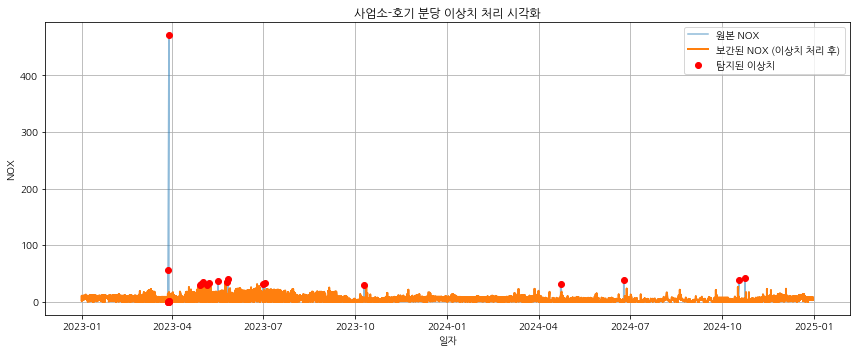

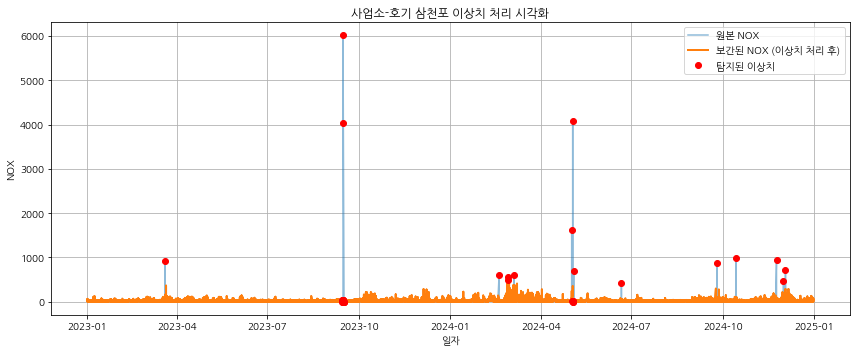

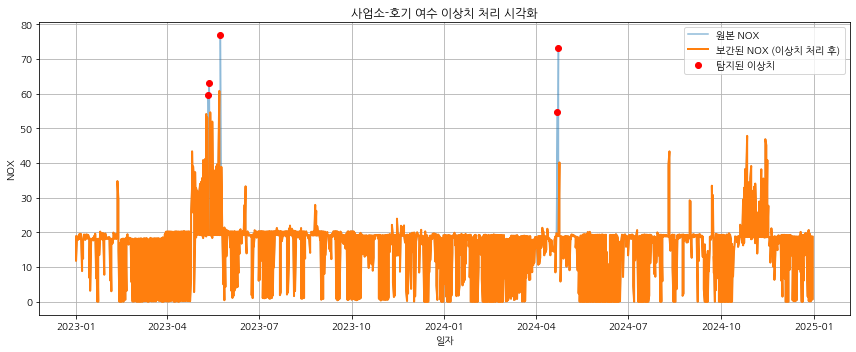

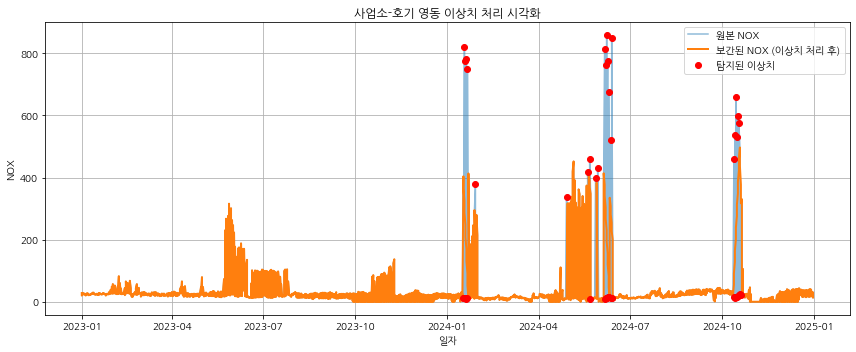

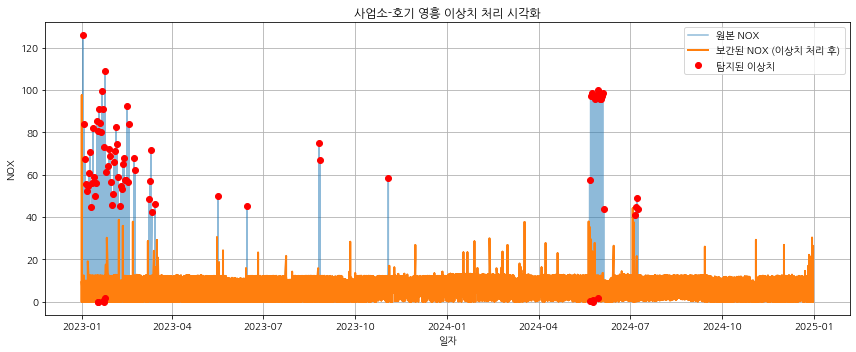

In [36]:
# df_preprocessed = df.groupby('사업소').apply(preprocess_unit_with_outlier_tracking).reset_index(drop=True)

for unit in df_preprocessed['사업소'].unique():
    plot_outlier_handling(df_preprocessed[df_preprocessed['사업소'] == unit], unit)

In [37]:
df_preprocessed.to_csv('사업소별_잔차전처리.csv', encoding='cp949', index=False)

In [ ]:
# LSTM-VAE

In [ ]:
# GAN

### 보간

In [ ]:
# 이웃값 평균 대체
df['NOX_cleaned'] = df['NOX']
df.loc[outliers, 'NOX_cleaned'] = df['NOX'].rolling(3, center=True).mean()


In [ ]:
# 선형 보간
df.loc[outliers, 'NOX'] = np.nan
df['NOX'] = df['NOX'].interpolate(method='linear')


### 극단적 이상치만 처리

## 정규화